In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


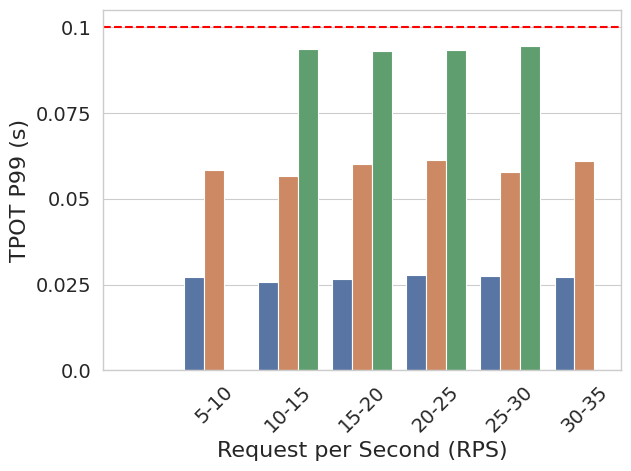

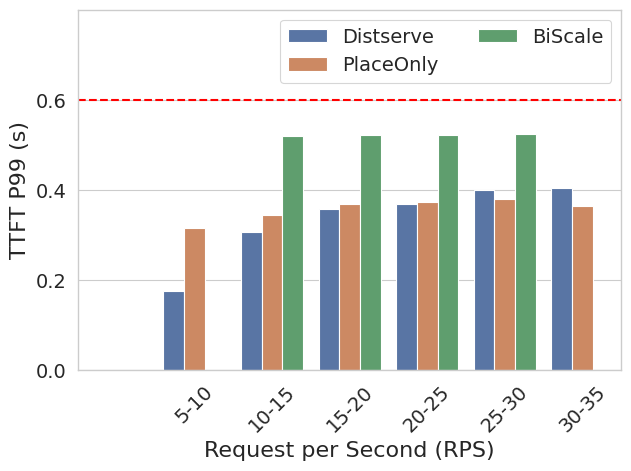

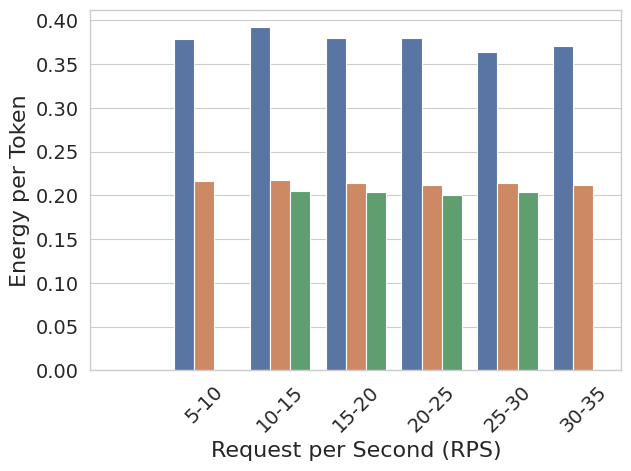

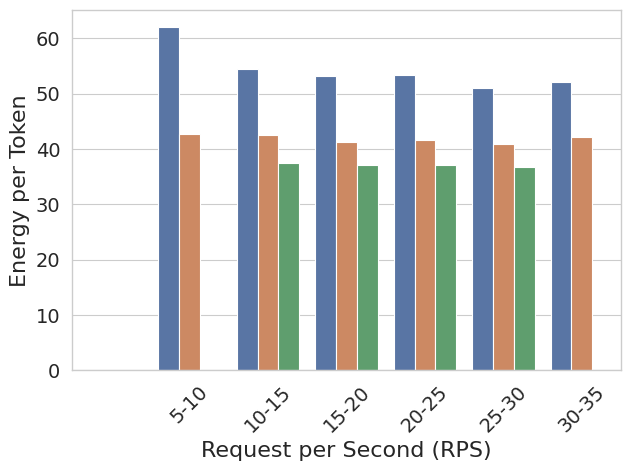

In [ ]:
path_disag = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/oracle_67_percent/profiler_logs_0_March29_oracle_fix/chunked/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/oracle_67_percent/profiler_logs_0_March29_oracle_fix/disag/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_7_node0': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_6_node0': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_5_node0': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_4_node0': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_3_node0': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_2_node0': 'Distserve 10',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_7_node0': 'Collocated FixFreq 85',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_6_node0': 'Collocated FixFreq 70',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_5_node0': 'Collocated FixFreq 55',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_4_node0': 'Collocated FixFreq 40',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_3_node0': 'Collocated FixFreq 25',
    'OURS_CHUNK_FEB24_REAL_P67_ORACLE_2_node0': 'Collocated FixFreq 10',
    'OURS_R5_JAN3_REAL_P67_ORACLE_7_node0': 'PlaceOnly 85',
    'OURS_R5_JAN3_REAL_P67_ORACLE_6_node0': 'PlaceOnly 70',
    'OURS_R5_JAN3_REAL_P67_ORACLE_5_node0': 'PlaceOnly 55',
    'OURS_R5_JAN3_REAL_P67_ORACLE_4_node0': 'PlaceOnly 40',
    'OURS_R5_JAN3_REAL_P67_ORACLE_3_node0': 'PlaceOnly 25',
    'OURS_R5_JAN3_REAL_P67_ORACLE_2_node0': 'PlaceOnly 10',
    'OURS_R5_JAN3_REAL_P67_ORACLE_7_DVFS_node0': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P67_ORACLE_6_DVFS_node0': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P67_ORACLE_5_DVFS_node0': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P67_ORACLE_4_DVFS_node0': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P67_ORACLE_3_DVFS_node0': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P67_ORACLE_2_DVFS_node0': 'BiScale 10',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale', 'Collocated FixFreq', 'Collocated DVFS'], ordered=True)
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'PlaceOnly', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('TPOT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.105)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('TTFT P99 (s)', fontsize=16)
ax.set_ylim(0, 0.8)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14)
ax.legend(title="", fontsize=14, ncol=2)
plt.tight_layout()
plt.savefig("figs/p67_oracle_ttft.pdf", format="pdf")

#################### Energy per token - decode ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=14)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_token_decode.pdf", format="pdf")

#################### Energy per token - prefill ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Request per Second (RPS)', fontsize=16)
ax.set_ylabel('Energy per Token', fontsize=16)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=14)
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_token_prefill.pdf", format="pdf")

In [96]:
# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_M'] = df_results.apply(
    lambda row: (1 - row['energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'PlaceOnly')
    ]['energy_per_token'].values[0]) * 100,
    axis=1
)
df_results[['expr_dir', 'energy_per_token', 'energy_norm_D', 'energy_norm_M']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_per_token,energy_norm_D,energy_norm_M
35,PlaceOnly 85,0.430315,29.867673,0.000000
56,PlaceOnly 70,0.424485,34.780279,0.000000
76,PlaceOnly 55,0.450941,22.167351,0.000000
92,PlaceOnly 40,0.438330,30.018458,0.000000
103,PlaceOnly 25,0.472836,42.798126,0.000000
112,PlaceOnly 10,0.701316,47.865604,0.000000
6,Distserve 85,0.613576,0.000000,-42.587598
12,Distserve 70,0.650854,0.000000,-53.327857
17,Distserve 55,0.579373,0.000000,-28.480787
21,Distserve 40,0.626351,0.000000,-42.894822
